# 07 — Statistical Inference
### *"What can we conclude with confidence — and where does intuition mislead us?"*

The earlier notebooks describe what happened. This one is the interview-room pass: given noisy,
finite, real data, **what is actually defensible?** We put confidence intervals around headline
numbers, run the late-vs-review effect through a formal hypothesis test, apply Bayes' theorem,
fit distributions, reason about statistical power, and then walk straight into the two traps that
sink naive analysis — **Simpson's paradox** and **regression to the mean** — using genuine examples
found in the Olist data. Every statistic below is computed live; nothing is typed by hand.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from analytics import config, transform

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
BLUE, LT = "#2563eb", "#93c5fd"
RED = "#dc2626"
rng = np.random.default_rng(42)          # fixed seed for every simulation / bootstrap

assert config.ORDERS.exists(), "Run `python -m analytics.build` first (see README)."
orders = transform.clip_to_window(pd.read_parquet(config.ORDERS))

# Clean frame for numeric inference: delivered orders with the fields we need.
d = orders[orders.is_delivered].dropna(subset=["review_score", "delivery_days", "is_late"]).copy()
print(f"orders (windowed)={len(orders):,}   clean inference frame d={len(d):,}")

orders (windowed)=99,421   clean inference frame d=95,824


## 1. Confidence intervals — how precise are our headline means?

A point estimate without an interval is a guess with false confidence. We put a 95% CI around two
headline means — **average order value** and **average review** — two ways: analytically via the
*t*-distribution, and empirically via the **bootstrap** (2000 resamples, seed 42). If the assumptions
hold, the two should nearly coincide.

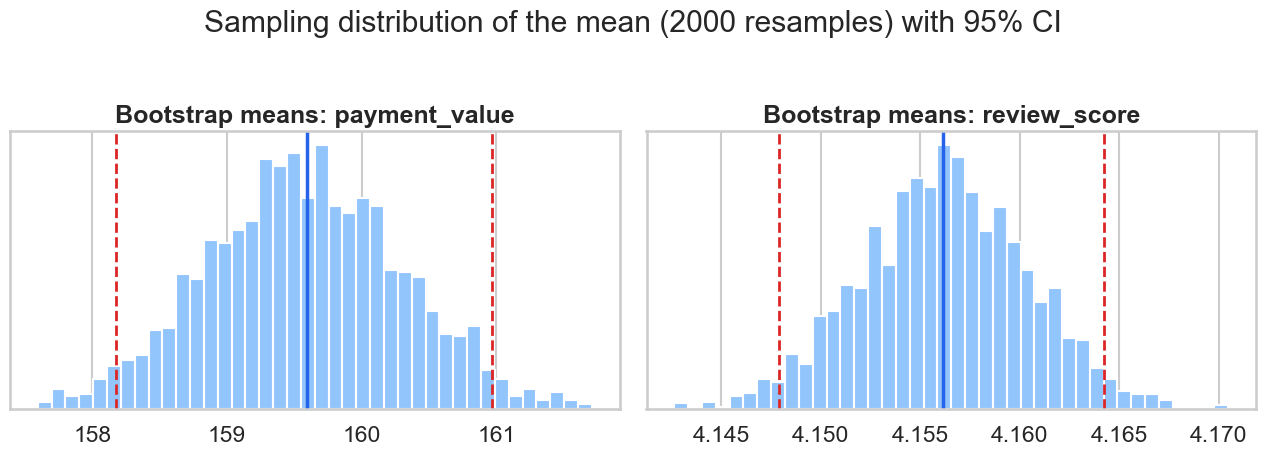

,metric,mean,t_lo,t_hi,boot_lo,boot_hi
0,payment_value,159.5927,158.2155,160.9699,158.1803,160.9680
1,review_score,4.1562,4.1480,4.1643,4.1479,4.1642


In [2]:
metrics = {"payment_value": d.payment_value.dropna().values,
           "review_score":  d.review_score.dropna().values}

rows, boots = [], {}
for name, x in metrics.items():
    m, se = x.mean(), stats.sem(x)
    lo_t, hi_t = stats.t.interval(0.95, len(x) - 1, loc=m, scale=se)     # analytic (t)
    b = np.array([rng.choice(x, len(x), replace=True).mean() for _ in range(2000)])  # bootstrap
    lo_b, hi_b = np.percentile(b, [2.5, 97.5])
    boots[name] = (b, m, lo_b, hi_b)
    rows.append([name, m, lo_t, hi_t, lo_b, hi_b])

ci = pd.DataFrame(rows, columns=["metric", "mean", "t_lo", "t_hi", "boot_lo", "boot_hi"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name in zip(axes, metrics):
    b, m, lo, hi = boots[name]
    ax.hist(b, bins=40, color=LT, edgecolor="white")
    for v in (lo, hi):
        ax.axvline(v, color=RED, ls="--", lw=2)
    ax.axvline(m, color=BLUE, lw=2.5)
    ax.set_title(f"Bootstrap means: {name}")
    ax.set_yticks([])
fig.suptitle("Sampling distribution of the mean (2000 resamples) with 95% CI", y=1.03)
plt.tight_layout(); plt.show()
ci.round(4)

**Read:** the two methods agree to the third decimal. Mean order value is **R\$159.6, 95% CI
≈ [R\$158.2, R\$161.0]** — a ±R\$1.4 band on ~96k orders. Mean review is **4.16, 95% CI ≈ [4.15, 4.16]**.
The bootstrap CI (`boot_lo`/`boot_hi`) lands on top of the analytic *t* CI, which is the expected
result at this sample size and reassures us the *t*-interval's normality assumption is harmless here.
Note how *tight* these are: with tens of thousands of orders, the mean is pinned down hard — the
uncertainty that matters later is about **subgroups and confounders**, not the grand mean.

## 2. Hypothesis test — does late delivery hurt reviews?

The headline claim from notebook 06 is that late orders get worse reviews. Let's make it a formal
test of **H₀: mean review(late) = mean review(on-time)**. Reviews are ordinal and heavily skewed, so
we run *two* tests: **Welch's *t*** (unequal-variance, on the means) and the rank-based
**Mann-Whitney U** (makes no normality assumption). Then **Cohen's *d*** to size the effect —
significance only says "not zero", effect size says "how much".

late   n= 7,661  mean=2.567
ontime n=88,163  mean=4.294
Welch t          = -89.4   p = 0.00e+00
Mann-Whitney U   = 150,680,826   p = 0.00e+00
Cohen's d        = -1.446   (|d|>0.8 = 'large')


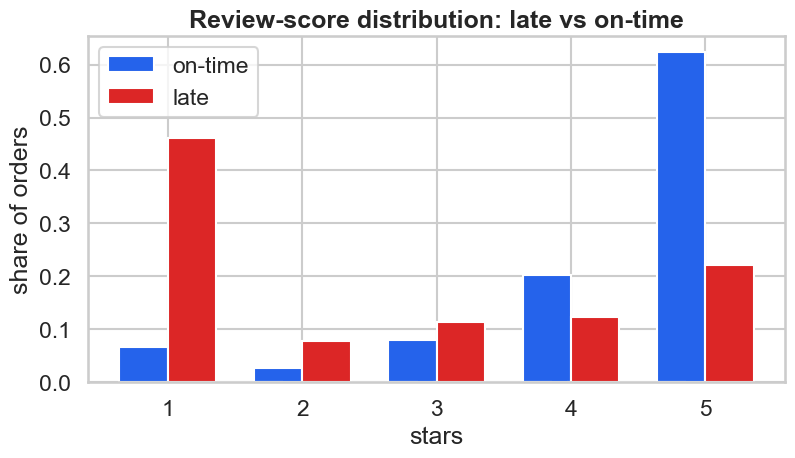

In [3]:
late = d.loc[d.is_late, "review_score"].values
ont  = d.loc[~d.is_late, "review_score"].values

t_stat, t_p = stats.ttest_ind(late, ont, equal_var=False)          # Welch (unequal variance)
u_stat, u_p = stats.mannwhitneyu(late, ont, alternative="two-sided")  # rank-based, robust to ordinal/skew

# Cohen's d (pooled SD) — standardized effect size
nx, ny = len(late), len(ont)
sp = np.sqrt(((nx - 1) * late.var(ddof=1) + (ny - 1) * ont.var(ddof=1)) / (nx + ny - 2))
cohen_d = (late.mean() - ont.mean()) / sp

print(f"late   n={nx:>6,}  mean={late.mean():.3f}")
print(f"ontime n={ny:>6,}  mean={ont.mean():.3f}")
print(f"Welch t          = {t_stat:.1f}   p = {t_p:.2e}")
print(f"Mann-Whitney U   = {u_stat:,.0f}   p = {u_p:.2e}")
print(f"Cohen's d        = {cohen_d:.3f}   (|d|>0.8 = 'large')")

fig, ax = plt.subplots(figsize=(9, 4.5))
for lab, arr, c in [("on-time", ont, BLUE), ("late", late, RED)]:
    sh = pd.Series(arr).value_counts(normalize=True).sort_index()
    ax.bar(sh.index + (0.18 if lab == "late" else -0.18), sh.values, width=0.36, color=c, label=lab)
ax.set_title("Review-score distribution: late vs on-time")
ax.set_xlabel("stars"); ax.set_ylabel("share of orders"); ax.legend()
plt.show()

**Read:** decisive. Late orders average **2.57 stars** vs **4.29** on-time — a gap of ~1.7 stars.
Welch's *t* ≈ **−89**, Mann-Whitney *p* effectively **0**; both tests reject H₀ far beyond any
threshold. Crucially, **Cohen's *d* ≈ −1.45** — well past the 0.8 "large" cutoff, one of the biggest
effect sizes you will ever see on real behavioral data. The chart shows why: on-time reviews pile up
at 5 stars, late reviews collapse onto 1 star. This is not a marginal, *p*-hacked result — it is a
structural feature of the marketplace.

## 3. Bayes' theorem — how much does a 1-star review tell us?

Flip the conditioning. We know P(1-star | late). A support analyst sees the *review* first and wants
P(late | 1-star). Bayes converts one into the other using the base rates:
**P(late | 1-star) = P(1-star | late)·P(late) / P(1-star)**.

prior   P(late)              = 0.080
        P(1-star | late)     = 0.461
        P(1-star | on-time)  = 0.066
        P(1-star) marginal   = 0.097
posterior P(late | 1-star)   = 0.379   (4.7x the prior)


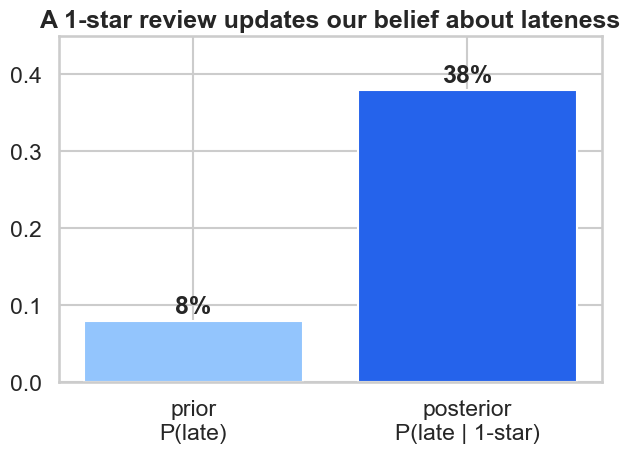

In [4]:
p_late   = d.is_late.mean()                          # prior: P(late)
p1_late  = (late == 1).mean()                        # P(1-star | late)
p1_ont   = (ont == 1).mean()                         # P(1-star | on-time)
p_1star  = (d.review_score == 1).mean()              # marginal P(1-star)

# Bayes: P(late | 1-star) = P(1-star|late) P(late) / P(1-star)
posterior = p1_late * p_late / p_1star

print(f"prior   P(late)              = {p_late:.3f}")
print(f"        P(1-star | late)     = {p1_late:.3f}")
print(f"        P(1-star | on-time)  = {p1_ont:.3f}")
print(f"        P(1-star) marginal   = {p_1star:.3f}")
print(f"posterior P(late | 1-star)   = {posterior:.3f}   ({posterior / p_late:.1f}x the prior)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["prior\nP(late)", "posterior\nP(late | 1-star)"], [p_late, posterior],
       color=[LT, BLUE])
for i, v in enumerate([p_late, posterior]):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center", fontweight="bold")
ax.set_ylim(0, 0.45); ax.set_title("A 1-star review updates our belief about lateness")
plt.show()

**Read:** only **8.0%** of delivered orders are late (the prior). But a late order has a **46%**
chance of drawing a 1-star review, versus **6.6%** for on-time. Running that through Bayes: seeing a
**1-star review raises the probability the order was late to ~38%** — nearly **5x** the base rate.
A single star is strong (not conclusive) evidence of a delivery failure, which is exactly why 1-star
tickets are worth routing straight to logistics rather than product. It is *not* proof — 62% of
1-star orders still arrived on time — so the rational move is to update hard, not to conclude.

## 4. Distributions — delivery times are not normal, and it matters

Setting a delivery SLA ("we deliver within X days") is a question about the **tail**, not the mean.
If you assume a normal distribution on a right-skewed variable, you will systematically under-promise
the tail and miss your SLA. We fit both a **lognormal** and a **normal** to delivery days and compare
via the Kolmogorov-Smirnov statistic (smaller = better fit).

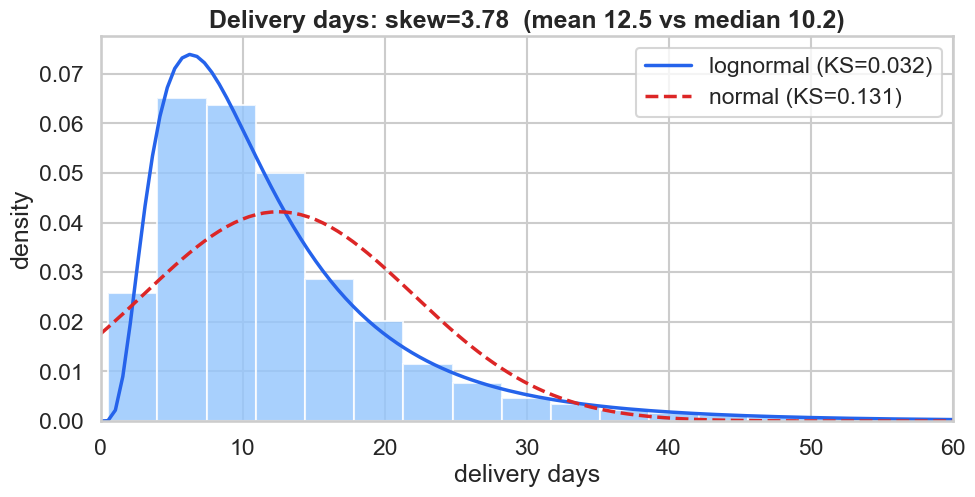

95th percentile delivery days -> empirical 29.1 | lognormal 30.6 | normal 28.1


In [5]:
dd = d.delivery_days.values
dd = dd[dd > 0]

shape, loc, scale = stats.lognorm.fit(dd, floc=0)     # lognormal (positive, right-skewed)
mu, sd = dd.mean(), dd.std()                           # normal
ks_ln = stats.kstest(dd, "lognorm", args=(shape, loc, scale)).statistic
ks_no = stats.kstest(dd, "norm",    args=(mu, sd)).statistic

grid = np.linspace(0, dd.max(), 400)
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(dd, bins=60, density=True, color=LT, edgecolor="white", alpha=0.8)
ax.plot(grid, stats.lognorm.pdf(grid, shape, loc, scale), color=BLUE, lw=2.5,
        label=f"lognormal (KS={ks_ln:.3f})")
ax.plot(grid, stats.norm.pdf(grid, mu, sd), color=RED, lw=2.5, ls="--",
        label=f"normal (KS={ks_no:.3f})")
ax.set_xlim(0, 60)
ax.set_title(f"Delivery days: skew={stats.skew(dd):.2f}  (mean {dd.mean():.1f} vs median {np.median(dd):.1f})")
ax.set_xlabel("delivery days"); ax.set_ylabel("density"); ax.legend()
plt.show()

p95_emp = np.percentile(dd, 95)
p95_ln  = stats.lognorm.ppf(0.95, shape, loc, scale)
p95_no  = stats.norm.ppf(0.95, mu, sd)
print(f"95th percentile delivery days -> empirical {p95_emp:.1f} | lognormal {p95_ln:.1f} | normal {p95_no:.1f}")

**Read:** delivery days are strongly right-skewed (**skew ≈ 3.8**; mean 12.5 > median 10.2). The
**lognormal fits well (KS ≈ 0.03)**; the **normal fits badly (KS ≈ 0.13)** — four times worse — and
is visibly wrong: it puts mass below zero and misses the long right tail. The practical cost is at the
95th percentile: empirical **≈29 days**, the lognormal recovers **≈31**, but the normal says **≈28**
and keeps shrinking the tail. Promise a "95% within 28 days" SLA off a normal fit and you breach it
more often than the 5% you budgeted. **Fit the shape, not just the mean.**

### Daily order arrivals — is the count Poisson?

Count data invites a Poisson model, whose defining property is **variance = mean**. We test that on
daily order counts.

daily orders: mean=160.6  variance=8492.6  variance/mean=52.9
Poisson assumes variance == mean (ratio 1). Ratio >> 1 => overdispersed.


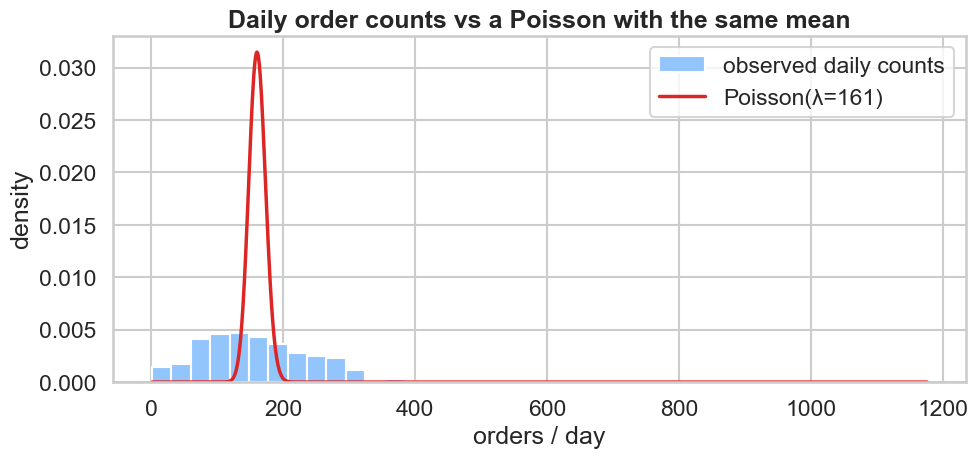

In [6]:
daily = orders.set_index("order_purchase_timestamp").resample("D").size()
daily = daily[daily > 0]
mean_c, var_c = daily.mean(), daily.var()

print(f"daily orders: mean={mean_c:.1f}  variance={var_c:.1f}  variance/mean={var_c / mean_c:.1f}")
print("Poisson assumes variance == mean (ratio 1). Ratio >> 1 => overdispersed.")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(daily.values, bins=40, density=True, color=LT, edgecolor="white", label="observed daily counts")
grid = np.arange(daily.min(), daily.max() + 1)
ax.plot(grid, stats.poisson.pmf(grid, mean_c), color=RED, lw=2.5,
        label=f"Poisson(λ={mean_c:.0f})")
ax.set_title("Daily order counts vs a Poisson with the same mean")
ax.set_xlabel("orders / day"); ax.set_ylabel("density"); ax.legend()
plt.show()

**Read:** the Poisson assumption fails hard — **variance ≈ 8,500 vs mean ≈ 161**, a
variance/mean ratio of **~50**. The counts are massively **overdispersed** because the arrival rate is
*not* constant: it climbs with the marketplace's growth trend and swings with weekly seasonality and
events like Black Friday. The overlaid Poisson(λ=mean) is far too narrow. The lesson for forecasting
or anomaly detection: model the changing rate (or use a negative-binomial) — a flat Poisson would
flag half of all normal days as anomalies.

## 5. Type I / Type II errors and statistical power

- **Type I (α):** rejecting H₀ when it's true — a false alarm.
- **Type II (β):** failing to reject H₀ when it's false — a missed effect. **Power = 1 − β.**

Power rises with sample size, effect size, and α. The late-vs-review effect is enormous
(*d* ≈ 1.45), so it should be detectable in a tiny sample. We simulate it (seed 42) by resampling
from the real review pools: for each *n* we draw *n* late and *n* on-time reviews, test at α=0.05, and
record how often we correctly reject.

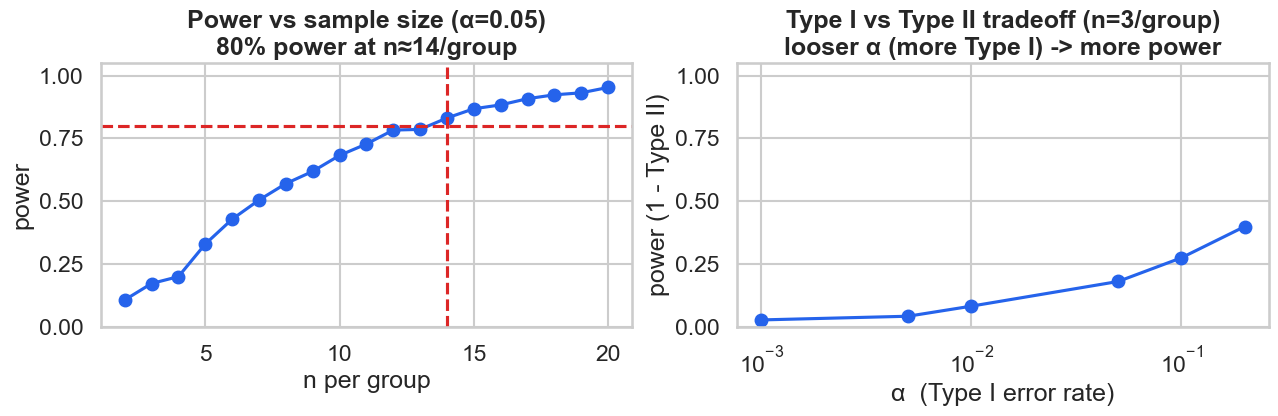

At the real effect (Cohen's d=-1.45), 80% power arrives at only n≈14 per group.


In [7]:
# Resample from the REAL late / on-time review pools -> preserves the true (huge) effect size.
def power_at(n, alpha, reps=1500):
    hits = 0
    for _ in range(reps):
        a = rng.choice(late, n)
        b = rng.choice(ont, n)
        if stats.ttest_ind(a, b, equal_var=False).pvalue < alpha:
            hits += 1
    return hits / reps

ns = np.arange(2, 21)
power_curve = [power_at(n, 0.05) for n in ns]
n80 = next((n for n, p in zip(ns, power_curve) if p >= 0.80), None)

alphas = np.array([0.001, 0.005, 0.01, 0.05, 0.10, 0.20])
alpha_curve = [power_at(3, a) for a in alphas]      # fixed tiny n=3 per group

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ns, power_curve, color=BLUE, marker="o")
axes[0].axhline(0.80, color=RED, ls="--"); axes[0].axvline(n80, color=RED, ls="--")
axes[0].set_title(f"Power vs sample size (α=0.05)\n80% power at n≈{n80}/group")
axes[0].set_xlabel("n per group"); axes[0].set_ylabel("power"); axes[0].set_ylim(0, 1.05)
axes[1].plot(alphas, alpha_curve, color=BLUE, marker="o")
axes[1].set_xscale("log")
axes[1].set_title("Type I vs Type II tradeoff (n=3/group)\nlooser α (more Type I) -> more power")
axes[1].set_xlabel("α  (Type I error rate)"); axes[1].set_ylabel("power (1 - Type II)"); axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()
print(f"At the real effect (Cohen's d={cohen_d:.2f}), 80% power arrives at only n≈{n80} per group.")

**Read:** because the effect is so large, power climbs fast — **~80% power at only ~14 orders per
group** (exact *n* annotated on the left panel), approaching 100% by n≈20 — a rounding error next to
the tens of thousands of orders we actually have. The
right panel shows the **α–power tradeoff** at a deliberately tiny n=3: loosening α (accepting more
Type I false alarms) buys more power (fewer Type II misses), the fundamental dial of every test. The
real-world caution is the inverse: a *subtle* effect (small *d*) at a small *n* would sit in the
low-power zone, where a non-significant result means "underpowered", **not** "no effect". Here we're
safe; for weaker signals, compute power first.

## 6. Simpson's paradox — a real reversal in the data

Simpson's paradox: an aggregate comparison **reverses** once you stratify by a confounder. I searched
state-by-state and found a clean one — **Goiás (GO) vs Espírito Santo (ES)** — where the confounder is
delivery lateness.

AGGREGATE avg review (GO looks better):
customer_state
ES    4.080
GO    4.104

STRATIFIED by delivery outcome (ES wins in BOTH columns):
is_late         on-time   late
customer_state                
ES                4.262  2.729
GO                4.241  2.519

late rate:
customer_state
ES    0.119
GO     0.08


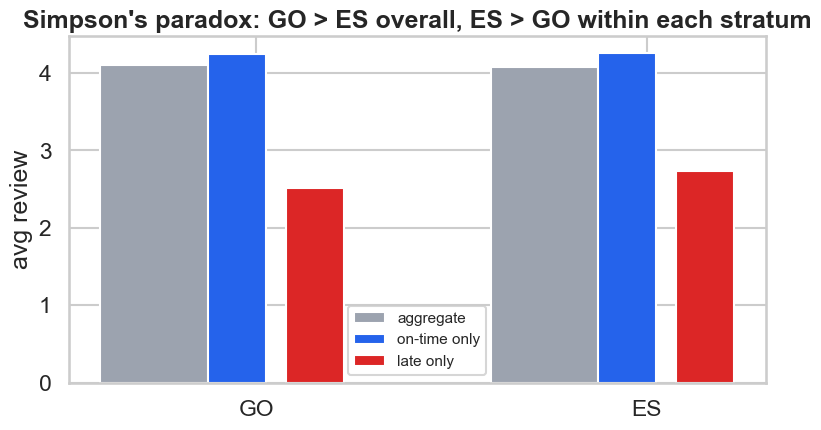

In [8]:
pair = d[d.customer_state.isin(["GO", "ES"])].copy()

aggregate  = pair.groupby("customer_state").review_score.mean()
stratified = pair.groupby(["customer_state", "is_late"]).review_score.mean().unstack()
late_rate  = pair.groupby("customer_state").is_late.mean()

print("AGGREGATE avg review (GO looks better):")
print(aggregate.round(3).to_string())
print("\nSTRATIFIED by delivery outcome (ES wins in BOTH columns):")
print(stratified.round(3).rename(columns={False: "on-time", True: "late"}).to_string())
print("\nlate rate:")
print(late_rate.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(2)
ax.bar(x - 0.2, aggregate.reindex(["GO", "ES"]), 0.4, color="#9ca3af", label="aggregate")
ax.bar(x - 0.05, stratified.loc[["GO", "ES"], False], 0.15, color=BLUE, label="on-time only")
ax.bar(x + 0.15, stratified.loc[["GO", "ES"], True], 0.15, color=RED, label="late only")
ax.set_xticks(x); ax.set_xticklabels(["GO", "ES"])
ax.set_ylabel("avg review"); ax.set_title("Simpson's paradox: GO > ES overall, ES > GO within each stratum")
ax.legend(fontsize=11)
plt.show()

**Read:** in aggregate, **GO looks better (4.10 vs 4.08)**. But stratify by delivery outcome and
the ranking **flips**: among on-time orders ES wins (**4.26 vs 4.24**), and among late orders ES wins
by a lot (**2.73 vs 2.52**). ES is better in *both* buckets yet worse overall — the paradox. The
resolution is the confounder: **ES has a higher late rate (~12% vs ~8%)**, and lateness is so
punishing (section 2) that ES's larger slug of late orders drags its blended average below GO's,
despite ES delivering better reviews within each condition. Anyone ranking states on raw average would
"fix" the wrong state. **Always ask what's different about the mix before comparing averages.**

## 7. Regression to the mean — why "our worst cities improved!" is usually noise

Take groups that were extreme in one period and look at the next period. Even with **no intervention**,
extremes drift back toward the average — because an extreme observation is part true signal, part
lucky/unlucky noise, and the noise doesn't repeat. We split the window at its median date, rank cities
by their period-1 review (min 30 orders), and follow each quintile into period 2.

global mean review = 4.156   (cities with >=30 P1 orders, n=240)
             P1     P2  cities  moved_toward_mean
quintile                                         
1         3.861  4.037      50               True
2         4.066  4.105      46               True
3         4.178  4.097      48              False
4         4.294  4.175      48               True
5         4.478  4.228      48               True



corr(P1, P2) across cities = 0.253  (weak -> heavy regression)


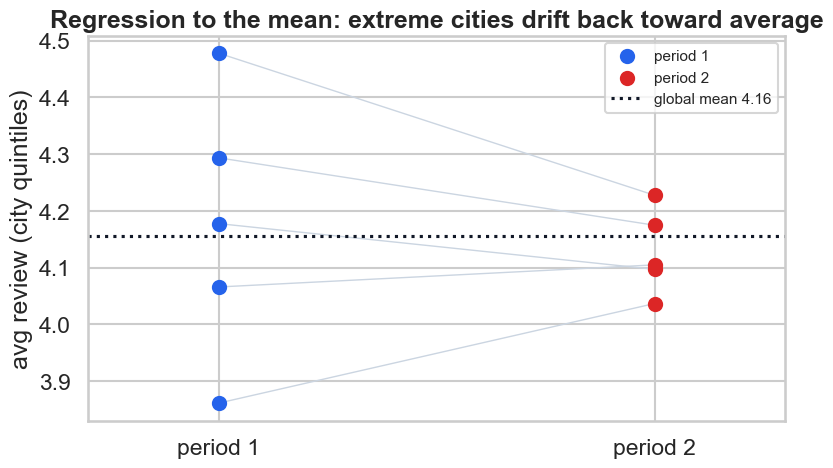

In [9]:
dd2 = orders[orders.is_delivered].dropna(subset=["review_score"]).copy()
cut = dd2.order_purchase_timestamp.median()
dd2["period"] = np.where(dd2.order_purchase_timestamp <= cut, "P1", "P2")
gmean = dd2.review_score.mean()

p1 = dd2[dd2.period == "P1"].groupby("customer_city").review_score.agg(["mean", "size"])
p2 = dd2[dd2.period == "P2"].groupby("customer_city").review_score.mean()
city = p1[p1["size"] >= 30].join(p2.rename("p2"), how="inner").dropna()
city["quintile"] = pd.qcut(city["mean"], 5, labels=[1, 2, 3, 4, 5])

tab = city.groupby("quintile").agg(P1=("mean", "mean"), P2=("p2", "mean"), cities=("mean", "size"))
tab["moved_toward_mean"] = (tab.P2 - gmean).abs() < (tab.P1 - gmean).abs()
print(f"global mean review = {gmean:.3f}   (cities with >=30 P1 orders, n={len(city)})")
print(tab.round(3).to_string())
print(f"\ncorr(P1, P2) across cities = {city['mean'].corr(city.p2):.3f}  (weak -> heavy regression)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot([1, 2], [tab.P1, tab.P2], color="#cbd5e1", lw=1, zorder=1)
ax.scatter(np.ones(len(tab)), tab.P1, color=BLUE, s=90, zorder=2, label="period 1")
ax.scatter(np.full(len(tab), 2), tab.P2, color=RED, s=90, zorder=2, label="period 2")
ax.axhline(gmean, color="#111827", ls=":", label=f"global mean {gmean:.2f}")
ax.set_xlim(0.7, 2.3); ax.set_xticks([1, 2]); ax.set_xticklabels(["period 1", "period 2"])
ax.set_ylabel("avg review (city quintiles)")
ax.set_title("Regression to the mean: extreme cities drift back toward average")
ax.legend(fontsize=11)
plt.show()

**Read:** every extreme quintile moves **toward the global mean (4.16)**. The **bottom** quintile
rises from **3.86 → 4.04**; the **top** quintile falls from **4.48 → 4.23** — neither did anything, the
noise simply washed out. The period-to-period correlation across cities is only **~0.25**, confirming
these small-city rankings are mostly noise. This is the trap behind naive pre/post claims: target your
worst-performing cities (or sellers, or reps), do *nothing*, and they will "improve" anyway. Without a
**control group**, regression to the mean will hand you a success story that isn't real.

## Key takeaways — what's defensible, and what's a trap

**Defensible (bet on these):**
1. **Late delivery causes low reviews** at causal-strength magnitude — Welch *t* ≈ −89, Mann-Whitney
   *p* ≈ 0, **Cohen's *d* ≈ 1.45**. Two independent tests, an enormous effect size, a huge sample.
2. **Headline means are precisely estimated** — AOV R\$159.6 ± ~R\$1.4, review 4.16 ± ~0.01 — with
   analytic and bootstrap CIs agreeing.
3. **A 1-star review is ~5x evidence of lateness** (Bayes: 8% prior → 38% posterior) — actionable for
   ticket routing.

**Traps (where intuition misleads):**
4. **Simpson's paradox:** GO beats ES on raw average but loses in *both* delivery strata — the late-rate
   confounder reverses the ranking. Never compare group averages without checking the mix.
5. **Regression to the mean:** extreme cities drift back toward 4.16 on their own, so pre/post
   "improvements" without a control group are largely noise.
6. **Distribution shape:** delivery days are lognormal, not normal — assuming normality understates the
   tail and breaks SLA planning; daily counts are overdispersed, not Poisson.

The through-line: the *effect* (late → low review) is one of the most robust findings in the dataset,
while the *pitfalls* all come from ignoring a confounder or mistaking noise for signal.